In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
 assessment_sales = pd.read_csv('assessment_sales.csv')
 lead_intake = pd.read_csv('lead_intake.csv')

In [3]:
assessment_sales.head(10)


,lead_id,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
0,L0001,"pump,lights",10.0,628.7,1
1,L0002,"lights,TV",2.5,151.0,1
2,L0003,"lights,fridge,TV",4.5,284.1,0
3,L0004,"lights,fridge",4.7,286.8,0
4,L0005,"lights,fridge",5.1,282.2,1
5,L0006,"AC,fridge,lights",10.9,586.2,0
6,L0007,"AC,fridge",9.1,378.0,0
7,L0008,"pump,fridge",11.1,761.7,1
8,L0009,"lights,TV",2.3,138.7,0
9,L0010,lights,1.3,96.5,0


In [4]:
lead_intake.head(10)

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram
5,L0006,Shahanan,8.2,garden_house,seasonal_garden,unstable,local_ad
6,L0007,Pasakhan,25.7,garden_house,mixed_use,unstable,local_ad
7,L0008,Bargan,9.5,farm,agriculture,unstable,referral
8,L0009,Bargan,11.6,rural_house,seasonal_garden,none,referral
9,L0010,Pasakhan,28.5,garden_house,seasonal_garden,none,local_ad


In [5]:
lead_intake.shape

(300, 7)

In [6]:
lead_intake.describe()

,distance_from_darab_km
count,300.000000
mean,26.994667
std,21.974070
min,1.500000
25%,12.475000
50%,17.800000
75%,33.025000
max,87.100000


In [7]:
assessment_sales.shape

(300, 5)

In [8]:
assessment_sales.describe()

,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
count,300.000000,300.000000,300.000000
mean,7.433333,459.250000,0.600000
std,3.398970,195.352413,0.490716
min,1.300000,96.500000,0.000000
25%,4.800000,289.500000,0.000000
50%,7.850000,495.100000,1.000000
75%,9.825000,619.225000,1.000000
max,16.600000,848.000000,1.000000


In [9]:
lead_intake.columns

Index(['lead_id', 'village', 'distance_from_darab_km', 'property_type',
       'usage_purpose', 'electricity_access', 'lead_source'],
      dtype='object')

In [10]:
assessment_sales.columns

Index(['lead_id', 'required_appliances', 'estimated_daily_energy_need_kwh',
       'quoted_price_m_toman', 'purchased'],
      dtype='object')

In [11]:
df=lead_intake.merge( assessment_sales, on = 'lead_id', how = 'inner')

In [12]:
df.head(10)

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral,"pump,lights",10.0,628.7,1
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral,"lights,TV",2.5,151.0,1
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral,"lights,fridge,TV",4.5,284.1,0
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad,"lights,fridge",4.7,286.8,0
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram,"lights,fridge",5.1,282.2,1
5,L0006,Shahanan,8.2,garden_house,seasonal_garden,unstable,local_ad,"AC,fridge,lights",10.9,586.2,0
6,L0007,Pasakhan,25.7,garden_house,mixed_use,unstable,local_ad,"AC,fridge",9.1,378.0,0
7,L0008,Bargan,9.5,farm,agriculture,unstable,referral,"pump,fridge",11.1,761.7,1
8,L0009,Bargan,11.6,rural_house,seasonal_garden,none,referral,"lights,TV",2.3,138.7,0
9,L0010,Pasakhan,28.5,garden_house,seasonal_garden,none,local_ad,lights,1.3,96.5,0


In [13]:
 B = set(lead_intake['lead_id']) == set(assessment_sales['lead_id'])

In [4]:
B

True

In [14]:
df.isna().sum()

lead_id                             0
village                             0
distance_from_darab_km              0
property_type                       0
usage_purpose                      12
electricity_access                  0
lead_source                        12
required_appliances                 0
estimated_daily_energy_need_kwh     0
quoted_price_m_toman                0
purchased                           0
dtype: int64

In [15]:
df['purchased'].value_counts()

purchased
1    180
0    120
Name: count, dtype: int64

In [16]:
df.to_csv('solar_leads_merged.csv', index=False)


In [4]:
df.describe()

,distance_from_darab_km,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
count,300.000000,300.000000,300.000000,300.000000
mean,26.994667,7.433333,459.250000,0.600000
std,21.974070,3.398970,195.352413,0.490716
min,1.500000,1.300000,96.500000,0.000000
25%,12.475000,4.800000,289.500000,0.000000
50%,17.800000,7.850000,495.100000,1.000000
75%,33.025000,9.825000,619.225000,1.000000
max,87.100000,16.600000,848.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   lead_id                          300 non-null    object 
 1   village                          300 non-null    object 
 2   distance_from_darab_km           300 non-null    float64
 3   property_type                    300 non-null    object 
 4   usage_purpose                    288 non-null    object 
 5   electricity_access               300 non-null    object 
 6   lead_source                      288 non-null    object 
 7   required_appliances              300 non-null    object 
 8   estimated_daily_energy_need_kwh  300 non-null    float64
 9   quoted_price_m_toman             300 non-null    float64
 10  purchased                        300 non-null    int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 25.9+ KB


,estimated_daily_energy_need_kwh,quoted_price_m_toman
required_appliances,,
lights,1.664286,146.185714
"lights,TV",2.390909,157.372727
"lights,fridge",4.478000,282.410000
"lights,fridge,TV",5.455000,310.782500
pump,8.144444,541.794444
"pump,lights",8.938889,599.103704
"pump,fridge",9.641935,665.025806
"AC,fridge",9.883333,513.333333
"AC,fridge,lights",11.881250,631.393750


In [17]:
df['required_appliances'].value_counts()

required_appliances
pump,lights         54
lights,fridge       50
lights,fridge,TV    40
pump                36
pump,fridge         31
lights,TV           22
pump,AC             19
AC,fridge           18
AC,fridge,lights    16
lights              14
Name: count, dtype: int64

In [18]:
df = pd.read_csv('solar_leads_merged')
df.head()

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral,"pump,lights",10.0,628.7,1
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral,"lights,TV",2.5,151.0,1
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral,"lights,fridge,TV",4.5,284.1,0
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad,"lights,fridge",4.7,286.8,0
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram,"lights,fridge",5.1,282.2,1


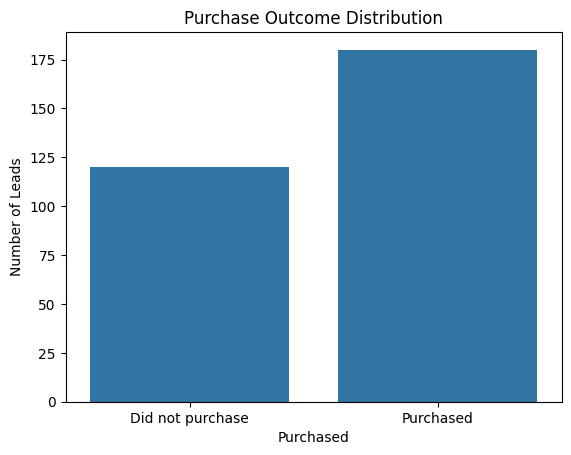

In [21]:
sns.countplot(data=df, x='purchased')
plt.title('Purchase Outcome Distribution')
plt.xlabel('Purchased')
plt.ylabel('Number of Leads')
plt.xticks([0, 1], ["Did not purchase", "Purchased"])
plt.show()

In [22]:
df['property_type'].value_counts()

property_type
farm            132
garden_house    111
rural_house      57
Name: count, dtype: int64

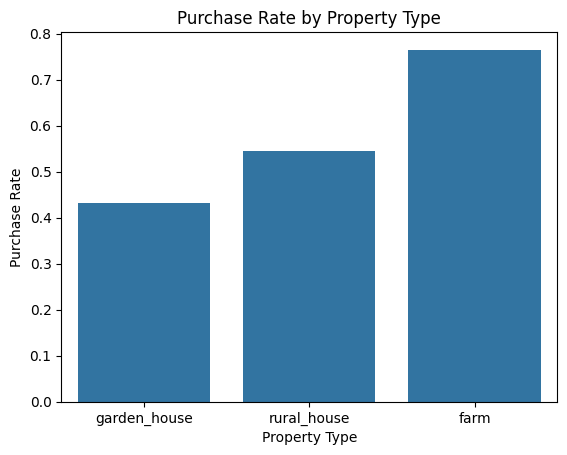

In [23]:
sns.barplot(
    data=df,
    x="property_type",
    y="purchased",
    errorbar=None
)
plt.title("Purchase Rate by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Purchase Rate")
plt.show()


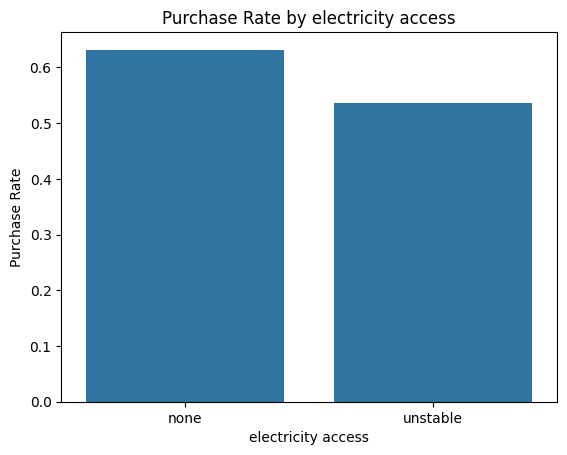

In [24]:
sns.barplot(
    data=df,
    x="electricity_access",
    y="purchased",
    errorbar=None
)
plt.title("Purchase Rate by electricity access")
plt.xlabel("electricity access")
plt.ylabel("Purchase Rate")
plt.show()

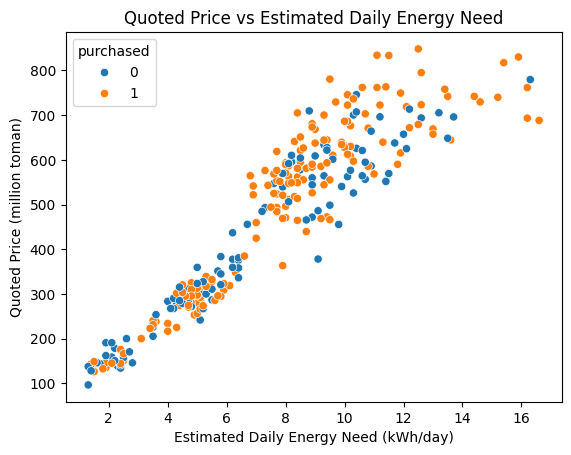

In [27]:
sns.scatterplot( 
    data= df,
    x = 'estimated_daily_energy_need_kwh',
    y = 'quoted_price_m_toman', 
    hue = 'purchased')
plt.title("Quoted Price vs Estimated Daily Energy Need")
plt.xlabel("Estimated Daily Energy Need (kWh/day)")
plt.ylabel("Quoted Price (million toman)")
plt.show()
          

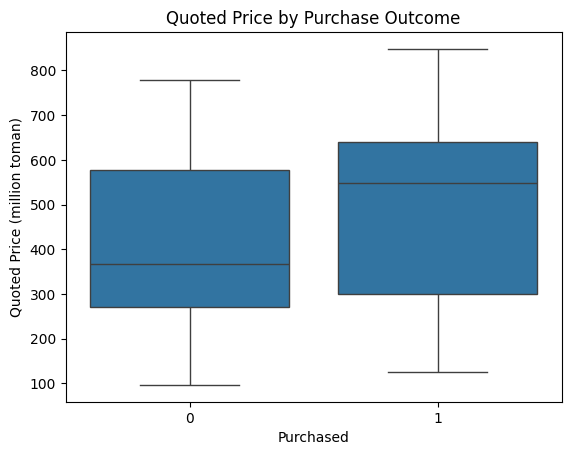

In [28]:
sns.boxplot(data=df, x="purchased", y="quoted_price_m_toman")

plt.title("Quoted Price by Purchase Outcome")
plt.xlabel("Purchased")
plt.ylabel("Quoted Price (million toman)")
plt.show()